In [278]:
import os
import sys
from loguru import logger
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from hippy2d.utils import get_testing_img

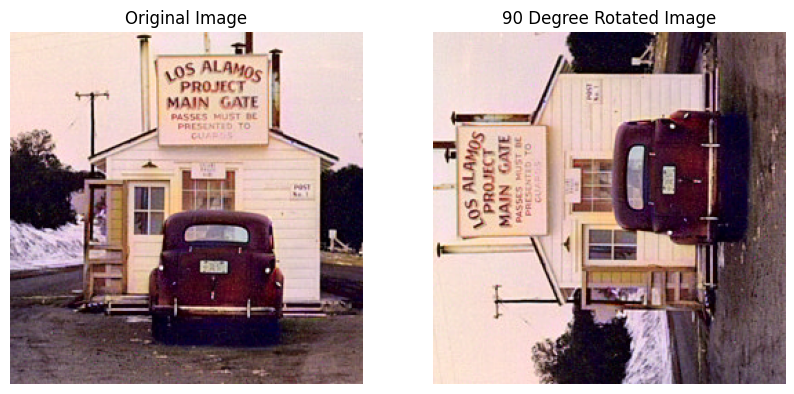

In [279]:
# Simulate RGB channels
test_img_rgb = get_testing_img(rgb=True)
test_img_rgb = transforms.ToTensor()(test_img_rgb).to(dtype=torch.float64)[None, : ].to(dtype=torch.float32)
rotated_img_rgb = torch.rot90(test_img_rgb, 1, [-2, -1]).to(dtype=torch.float32)

# Plot the images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img_rgb[0].permute(1, 2, 0).numpy(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rotated_img_rgb[0].permute(1, 2, 0).numpy(), cmap='gray')
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()

# Standardize the images 
mean = test_img_rgb.mean(dim=[0, 2, 3], keepdim=True)
std = test_img_rgb.std(dim=[0, 2, 3], keepdim=True)
test_img_rgb = (test_img_rgb - mean) / std
rotated_img_rgb = (rotated_img_rgb - mean) / std

In [288]:
import escnn
r2_act = escnn.gspaces.rot2dOnR2(N=-1, maximum_frequency=3)
in_type = escnn.nn.FieldType(r2_act, [r2_act.trivial_repr] * 3)  # RGB input
out_channels = 4
kernel_size = 7
irreps = None

if irreps is None: 
    irreps = []
    for n, irr in enumerate(r2_act.fibergroup.irreps()):
        if not irr.is_trivial():
            irreps += [irr] * int(irr.size // irr.sum_of_squares_constituents)
    irreps = list(irreps)


trivials = escnn.nn.FieldType(r2_act, [r2_act.trivial_repr] * out_channels)
norm_factor = escnn.group.directsum([r2_act.irrep(1)]  * out_channels, name="norm_factor")
norm_factor = escnn.nn.FieldType(r2_act, [norm_factor])
non_trivials = escnn.nn.FieldType(r2_act, sorted(irreps * out_channels, key=lambda r: r.id))
conv_type = trivials + norm_factor + non_trivials
# Prepare convolutional layer
conv = escnn.nn.R2Conv(in_type,
                       conv_type,
                       kernel_size=kernel_size,
                       padding=2,
                       sigma=0.6,
                       initialize=True)
conv.weights = torch.nn.Parameter(torch.ones_like(conv.weights) * 0.01)

In [289]:
x = test_img_rgb
x = escnn.nn.GeometricTensor(x, in_type)
x = conv(x)
x.shape
out_type = conv.out_type

In [292]:
inv_layer = InvariantLayer(r2_act=r2_act, in_type=conv_type, in_channels=out_channels)
def _simple_net(img):
    x = img
    x = escnn.nn.GeometricTensor(x, in_type)
    x = conv(x)
    x = inv_layer(x)
    return x

invariants = _simple_net(test_img_rgb)
rotated_invariants = _simple_net(rotated_img_rgb)

# assert close
torch.testing.assert_close(invariants.tensor, torch.rot90(rotated_invariants.tensor, k=-1, dims=[-2, -1])) 

In [ ]:
import torch 
vectors = np.array([[2.0, 0.0], [1.0, 1.0], [0.0, 2.0], [-1.0, 1.0], [-2.0, 0.0], [-1.0, -1.0], [0.0, -2.0], [1.0, -1.0]])
vectors = torch.tensor(vectors, dtype=torch.float32)

torch.linalg.norm(vectors, dim=1)



tensor([2.0000, 1.4142, 2.0000, 1.4142, 2.0000, 1.4142, 2.0000, 1.4142])